In [ ]:
from google.colab import files

uploaded=files.upload()

Saving heart.csv to heart.csv


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])

In [ ]:

print(df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [ ]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Number of duplicate rows before removal: 723
Number of duplicate rows after removal: 0


In [ ]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

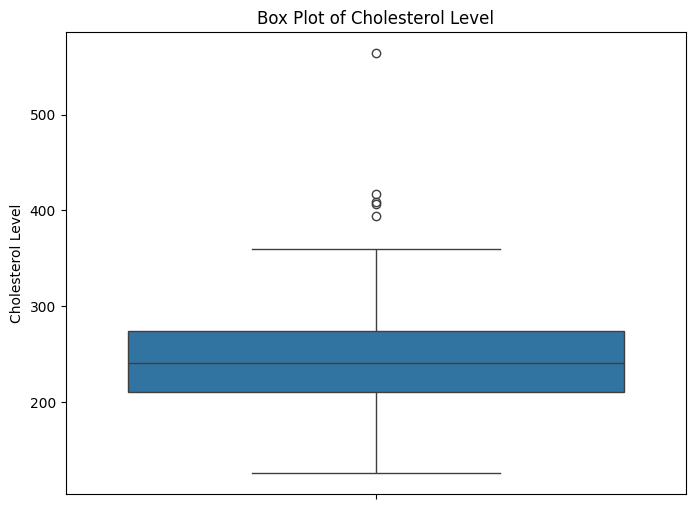

In [ ]:
 plt.figure(figsize=(8, 6))
sns.boxplot(y=df['chol'])
plt.ylabel('Cholesterol Level')
plt.title('Box Plot of Cholesterol Level')
plt.show()

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2



Target (y) head:


,target
0,0
1,0
2,0
3,0
4,0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Identify numerical columns to scale based on the heart disease dataset
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("Features (X) after scaling numerical columns:")
display(X.head())

Features (X) after scaling numerical columns:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.267966,1,0,-0.376556,-0.667728,0,1,0.806035,0,-0.037124,2,2,3
1,-0.157260,1,0,0.478910,-0.841918,1,0,0.237495,1,1.773958,0,0,3
2,1.724733,1,0,0.764066,-1.403197,0,1,-1.074521,1,1.342748,0,0,3
3,0.728383,1,0,0.935159,-0.841918,0,1,0.499898,0,-0.899544,2,1,3
4,0.839089,0,0,0.364848,0.919336,1,1,-1.905464,0,0.739054,1,3,2


In [ ]:
from sklearn.model_selection import train_test_split

print("Imported train_test_split successfully.")

Imported train_test_split successfully.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (241, 13)
Shape of X_test: (61, 13)
Shape of y_train: (241,)
Shape of y_test: (61,)


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=9)

In [ ]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import classification_report
y_pred_test = log_model.predict(X_test)
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.29      0.30      0.30        23
           1       0.57      0.55      0.56        38

    accuracy                           0.46        61
   macro avg       0.43      0.43      0.43        61
weighted avg       0.46      0.46      0.46        61



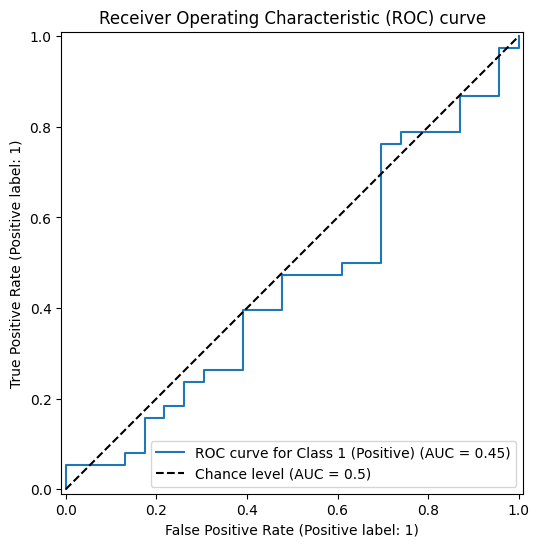

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt


y_score = log_model.predict_proba(X_test)



plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_score[:, 1],
    name="ROC curve for Class 1 (Positive)",
    ax=plt.gca(),
    plot_chance_level=True
)

plt.title('Receiver Operating Characteristic (ROC) curve')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


Text(0.5, 1.0, 'Heart Disease Target Distribution')

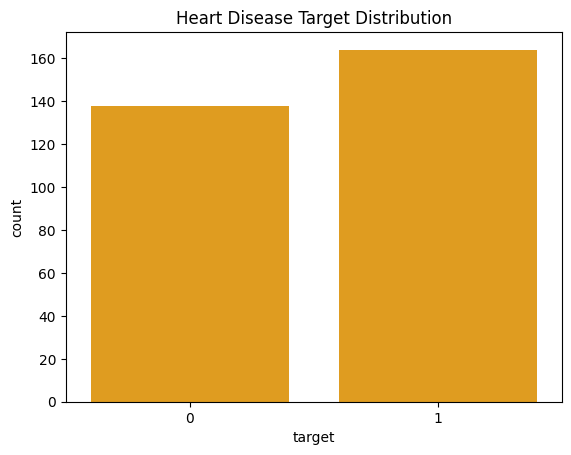

In [ ]:
sns.countplot(x='target',data=df,color='orange')
plt.title('Heart Disease Target Distribution')

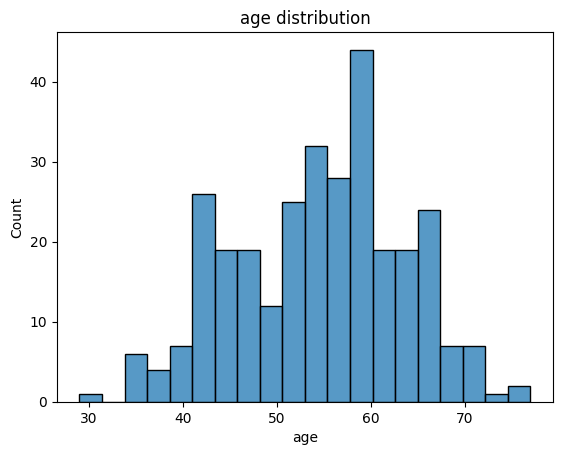

In [ ]:
sns.histplot(data=df,x='age',bins=20)
plt.title('age distribution')
plt.show()

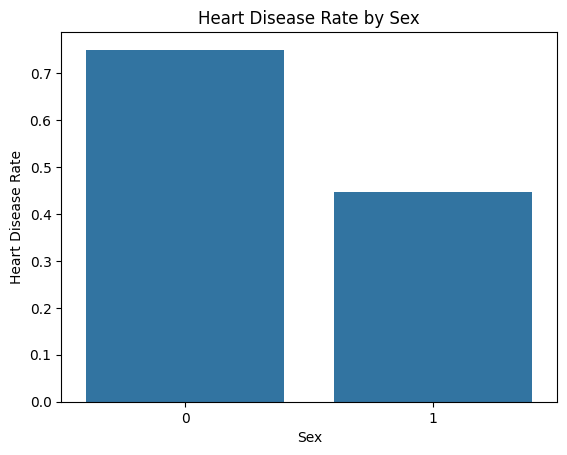

In [ ]:
sex_heart_disease_rate = df.groupby('sex')['target'].mean()
sns.barplot(x=sex_heart_disease_rate.index, y=sex_heart_disease_rate.values)
plt.title('Heart Disease Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Heart Disease Rate')
plt.show()

In [ ]:
# correlation matrix values
corr_matrix=df.corr(numeric_only=True)
print(corr_matrix)

               age       sex        cp  trestbps      chol       fbs  \
age       1.000000 -0.094962 -0.063107  0.283121  0.207216  0.119492   
sex      -0.094962  1.000000 -0.051740 -0.057647 -0.195571  0.046022   
cp       -0.063107 -0.051740  1.000000  0.046486 -0.072682  0.096018   
trestbps  0.283121 -0.057647  0.046486  1.000000  0.125256  0.178125   
chol      0.207216 -0.195571 -0.072682  0.125256  1.000000  0.011428   
fbs       0.119492  0.046022  0.096018  0.178125  0.011428  1.000000   
restecg  -0.111590 -0.060351  0.041561 -0.115367 -0.147602 -0.083081   
thalach  -0.395235 -0.046439  0.293367 -0.048023 -0.005308 -0.007169   
exang     0.093216  0.143460 -0.392937  0.068526  0.064099  0.024729   
oldpeak   0.206040  0.098322 -0.146692  0.194600  0.050086  0.004514   
slope    -0.164124 -0.032990  0.116854 -0.122873  0.000417 -0.058654   
ca        0.302261  0.113060 -0.195356  0.099248  0.086878  0.144935   
thal      0.065317  0.211452 -0.160370  0.062870  0.096810 -0.03

In [ ]:
corr_matrix['target'].sort_values(ascending=False)

,target
target,1.000000
cp,0.432080
thalach,0.419955
slope,0.343940
restecg,0.134874
fbs,-0.026826
chol,-0.081437
trestbps,-0.146269
age,-0.221476
sex,-0.283609


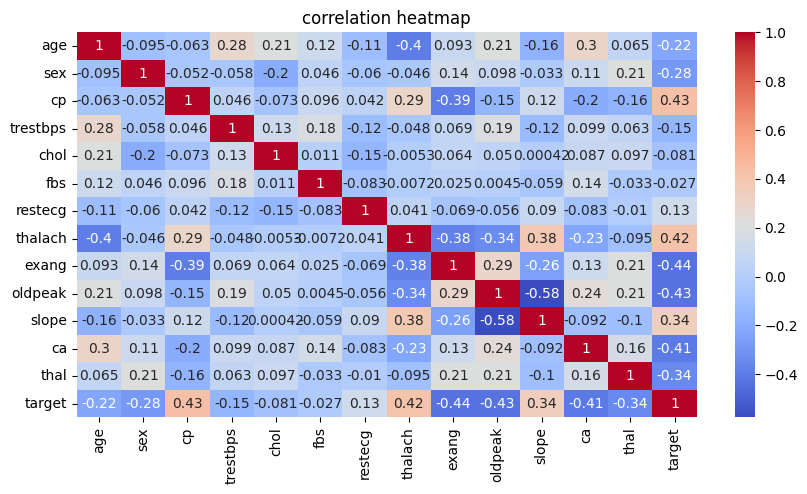

In [ ]:

plt.figure(figsize=(10,5))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [ ]:
from sklearn.svm import SVC
model=SVC()
model.fit(X_train,y_train)

SVC()

In [ ]:
ypre_train=model.predict(X_train)
ypre_test=model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train,ypre_train))
print(accuracy_score(y_test,ypre_test))

0.6846473029045643
0.5245901639344263


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train,y_train)

KNeighborsClassifier()

In [ ]:
y_pred_train = knn_model.predict(X_train)
y_pred_test = knn_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train,y_pred_train))
print(accuracy_score(y_test,y_pred_test))

0.6970954356846473
0.5737704918032787


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(knn_model,X,y,cv=5)
scores.mean()

np.float64(0.8046448087431693)

In [ ]:
from sklearn.svm import SVC
svm_model = SVC()
svm_model.fit(X_train,y_train)

SVC()

In [ ]:
y_pred_train = svm_model.predict(X_train)
y_pred_test = svm_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train,y_pred_train))
print(accuracy_score(y_test,y_pred_test))

0.6846473029045643
0.5245901639344263


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=8,random_state=0)
model.fit(X_train,y_train)
ypred_train=model.predict(X_train)
ypred_test=model.predict(X_test)
from sklearn.metrics import accuracy_score
print("train accuracy:",accuracy_score(y_train,ypred_train))
print("test accuracy:",accuracy_score(y_test,ypred_test))

scores=cross_val_score(model,X,y,cv=5)
print("cross validation score:",scores.mean())

train accuracy: 0.966804979253112
test accuracy: 0.5573770491803278
cross validation score: 0.7779781420765028


In [ ]:
import numpy as np
df=pd.DataFrame({"algorithm":['Logistic Regression','KNN','SVM','Decision Tree','Random Forest'],
                 "train_accuracy":[0.42,1.32,0.58,0.54,0.22],
                 "test_accuracy":[0.49,0.38,0.12,0.89,0.33],
                 "cv_scores":[1.0,0.66,1.29,0.78,0.77]})
df

,algorithm,train_accuracy,test_accuracy,cv_scores
0,Logistic Regression,0.42,0.49,1.00
1,KNN,1.32,0.38,0.66
2,SVM,0.58,0.12,1.29
3,Decision Tree,0.54,0.89,0.78
4,Random Forest,0.22,0.33,0.77
